# Laboratorio: Algoritmo di discesa del gradiente

### Applicare l'algoritmo di discesa del gradiente alla seguente funzione.
$$
f : \mathbb{R}^2 \rightarrow \mathbb{R}
$$
$$
f(x, y) = x \log(y)
$$

Ovvero, usare `numpy` e `matplotlib` per:
- definire la funzione
- visualizzare la funzione
    - prima definire una meshgrid (visualizzare la meshgrid con plot scatter)
    - poi visualizzare la superficie
    - infine, visualizzare le sue curve di livello
- calcolare il gradiente della funzione
- definire una strategia di arresto
- implementare l'algoritmo di discesa del gradiente
- applicare l'algoritmo alla funzione f
- visualizzare il percorso individuato dall'algoritmo
    - visualizzazione sulla superficie
    - visualizzazione "dall'alto"

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return np.array(x * np.log(y))

In [5]:
lin_x = np.linspace(-5, 5)
lin_y = np.linspace(0.5, 5)

xy = np.meshgrid(lin_x, lin_y)

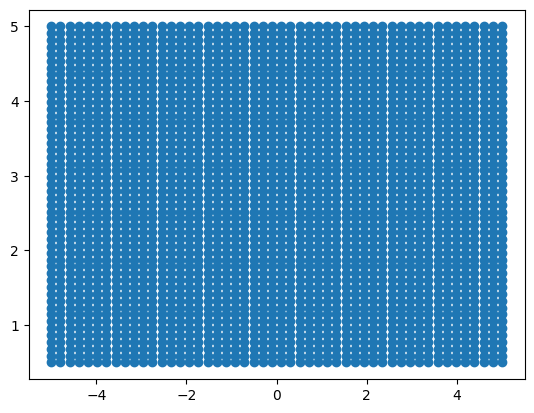

In [6]:
plt.scatter(*xy)
plt.show()

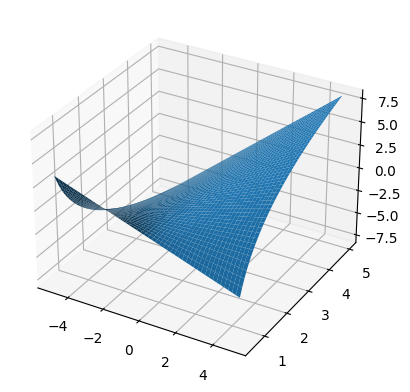

In [17]:
ax = plt.axes(projection='3d')

ax.plot_surface(*xy, f(*xy) )

plt.show()


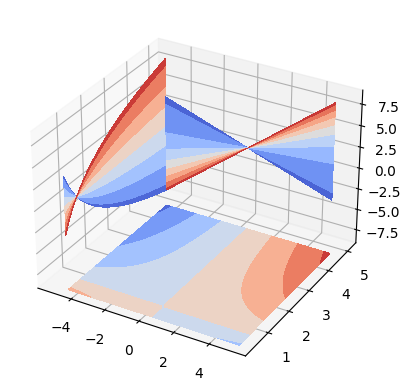

In [18]:
lin_x = np.linspace(-5, 5)
lin_y = np.linspace(0.5, 5)

x, y = np.meshgrid(lin_x, lin_y)
z = f(x, y)

ax2 = plt.axes(projection='3d')
# ax2.plot_surface(x, y, z)

ax2.contourf(x, y, z, zdir='z', offset=-10, cmap='coolwarm')
ax2.contourf(x, y, z, zdir='y', offset=5, cmap='coolwarm')
ax2.contourf(x, y, z, zdir='x', offset=-5, cmap='coolwarm')

plt.show()

Gradiente di $f$:
$$
\frac{\partial f}{\partial x} = \log(y), \qquad \frac{\partial f}{\partial y} = \frac{x}{y}
$$

In [19]:
def grad_f(x, y):
    return np.array([np.log(y), x / y])

Per sapere qual è un punto stazionario a cui puntare con il metodo di discesa, dobbiamo vedere quando il gradiente si annulla.

Questo succede per $x = 0$ e $y = 1$.

La strategia di terminazione diventa quindi:
$$
||\nabla f|| < \varepsilon
$$

oppure:
$$
|| (x_k, y_k) - (0, 1) || < \varepsilon
$$

In [20]:
def gradient_descent(x_0, eta, stat_pt = np.array([0, 1]), max_iter=100, epsilon=1e-6):

    x = [x_0]

    i = 0

    while i < max_iter and np.linalg.norm(x[-1] - stat_pt) >= epsilon:

        x_new = x[-1] - eta * grad_f(*x[-1])

        x.append(x_new)

        i += 1

    print("Numero di iterazioni:", i)

    return np.array(x).transpose()

Numero di iterazioni: 100


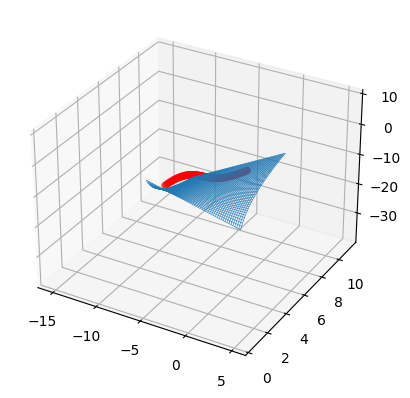

In [21]:
x_0 = np.array([2, 4])
eta = 0.1

min_x = gradient_descent(x_0, eta)

ax3 = plt.axes(projection='3d')

ax3.plot_wireframe(x, y, f(x, y), linewidth=0.4)
ax3.scatter(*min_x, f(*min_x), c='r')

plt.show()

### Applicare poi l'algoritmo alle seguenti funzioni.


#### Loss $L_1$, detta "geometria del taxi".
$$
L_1 : \mathbb{R}^{2N} \rightarrow \mathbb{R}
$$

$$
L_1(\underline{x}, \underline{y}) = \frac{1}{N} \sum_{i = 1}^N {| x_i - y_i |}
$$
dove $\underline{x} \in \mathbb{R}^N$ e $\underline{y} \in \mathbb{R}^N$.


*Suggerimento:* per visualizzare la funzione, prendere ad esempio $N = 1$.

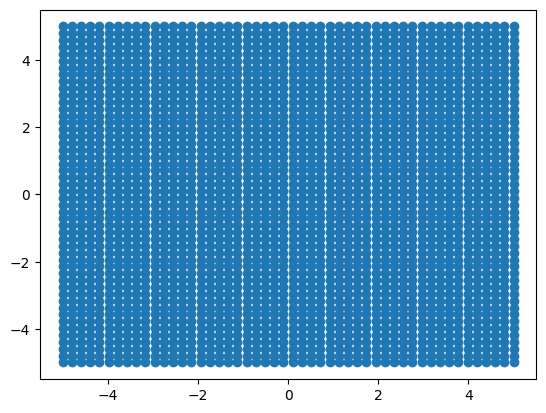

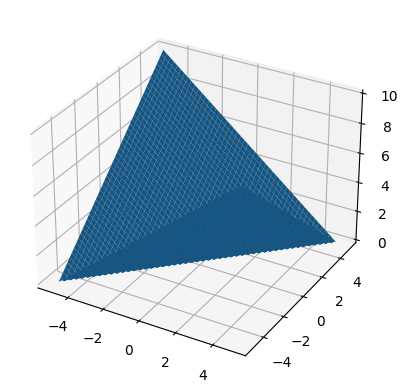

In [22]:
def f(x, y):
    return np.abs(x - y)

lin_x = np.linspace(-5, 5)
lin_y = np.linspace(-5, 5)

xy = np.meshgrid(lin_x, lin_y)

plt.scatter(*xy)
plt.show()

ax = plt.axes(projection='3d')

ax.plot_surface(*xy, f(*xy) )


Numero di iterazioni: 30


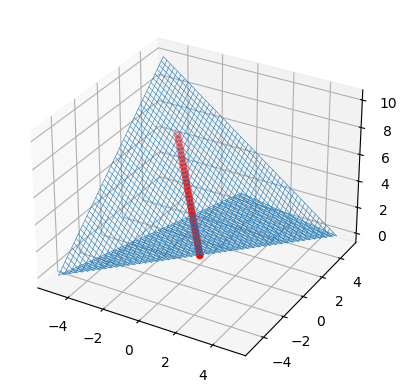

In [23]:
def grad_f(x, y):
    return np.array([x - y, y - x] / np.abs(x - y))

x_0 = np.array([-3, 3])
eta = 0.1

min_x = gradient_descent(x_0, eta, stat_pt=np.array([0, 0]))

ax3 = plt.axes(projection='3d')

ax3.plot_wireframe(*xy, f(*xy), linewidth=0.4)
ax3.scatter(*min_x, f(*min_x), c='r')

plt.show()

In [24]:
N = 2

def f(x, y):
    return 1 / N * np.sum( np.linalg.norm(x - y, ord=1) )

def grad_f(x, y):
    return 1 / N * np.array([x - y, y - x] / np.linalg.norm(x - y, ord=1))

x_0, y_0 = np.array([-3, 3]), np.array([3, -3])
eta = 0.5

stat_pt = np.array([[0, 0], [0, 0]])

min_x = gradient_descent([x_0, y_0], eta, stat_pt=stat_pt)

print(min_x)
print(f(*min_x[:, :, -1]))

print(np.linalg.norm(min_x[:, :, -1] - stat_pt, ord=1))


Numero di iterazioni: 24
[[[-3.    -2.875 -2.75  -2.625 -2.5   -2.375 -2.25  -2.125 -2.    -1.875
   -1.75  -1.625 -1.5   -1.375 -1.25  -1.125 -1.    -0.875 -0.75  -0.625
   -0.5   -0.375 -0.25  -0.125  0.   ]
  [ 3.     2.875  2.75   2.625  2.5    2.375  2.25   2.125  2.     1.875
    1.75   1.625  1.5    1.375  1.25   1.125  1.     0.875  0.75   0.625
    0.5    0.375  0.25   0.125  0.   ]]

 [[ 3.     2.875  2.75   2.625  2.5    2.375  2.25   2.125  2.     1.875
    1.75   1.625  1.5    1.375  1.25   1.125  1.     0.875  0.75   0.625
    0.5    0.375  0.25   0.125  0.   ]
  [-3.    -2.875 -2.75  -2.625 -2.5   -2.375 -2.25  -2.125 -2.    -1.875
   -1.75  -1.625 -1.5   -1.375 -1.25  -1.125 -1.    -0.875 -0.75  -0.625
   -0.5   -0.375 -0.25  -0.125  0.   ]]]
0.0
0.0


#### Loss $L_2$, detta MSE (Mean Squared Error).
$$
L_2 : \mathbb{R}^{2N} \rightarrow \mathbb{R}
$$

$$
L_2(\underline{x}, \underline{y}) = \frac{1}{2N} \sum_{i = 1}^N {| x_i - y_i |}^2
$$
dove $\underline{x} \in \mathbb{R}^N$ e $\underline{y} \in \mathbb{R}^N$.

(50, 50)
2


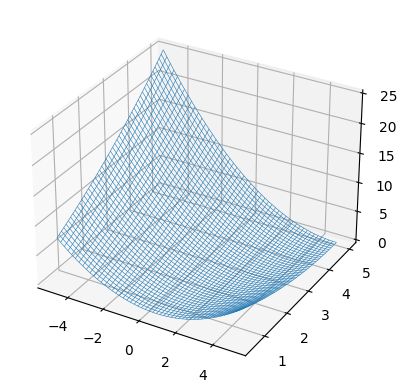

Numero di iterazioni: 23
[[[-3.00000000e+00 -1.50000000e+00 -7.50000000e-01 -3.75000000e-01
   -1.87500000e-01 -9.37500000e-02 -4.68750000e-02 -2.34375000e-02
   -1.17187500e-02 -5.85937500e-03 -2.92968750e-03 -1.46484375e-03
   -7.32421875e-04 -3.66210938e-04 -1.83105469e-04 -9.15527344e-05
   -4.57763672e-05 -2.28881836e-05 -1.14440918e-05 -5.72204590e-06
   -2.86102295e-06 -1.43051147e-06 -7.15255737e-07 -3.57627869e-07]
  [ 3.00000000e+00  1.50000000e+00  7.50000000e-01  3.75000000e-01
    1.87500000e-01  9.37500000e-02  4.68750000e-02  2.34375000e-02
    1.17187500e-02  5.85937500e-03  2.92968750e-03  1.46484375e-03
    7.32421875e-04  3.66210938e-04  1.83105469e-04  9.15527344e-05
    4.57763672e-05  2.28881836e-05  1.14440918e-05  5.72204590e-06
    2.86102295e-06  1.43051147e-06  7.15255737e-07  3.57627869e-07]]

 [[ 3.00000000e+00  1.50000000e+00  7.50000000e-01  3.75000000e-01
    1.87500000e-01  9.37500000e-02  4.68750000e-02  2.34375000e-02
    1.17187500e-02  5.85937500e-0

In [50]:
N = 2

def f(x, y):
    return 1 / (2 * N) * np.abs(x - y) ** 2

def grad_f(x, y):
    return 1 / N * np.array([x - y, y - x])


lin_x = np.linspace(-5, 5)
lin_y = np.linspace(0.5, 5)

x, y = np.meshgrid(lin_x, lin_y)

z = f(x, y)

print(z.shape)
print(z.ndim)

ax = plt.axes(projection='3d')
ax.plot_wireframe(x, y, z, linewidth=0.4)

plt.show()


x_0, y_0 = np.array([-3, 3]), np.array([3, -3])
eta = 0.5

stat_pt = np.array([[0, 0], [0, 0]])

min_x = gradient_descent([x_0, y_0], eta, stat_pt=stat_pt)

print(min_x)
print(f(*min_x[:, :, -1]))

print(np.linalg.norm(min_x[:, :, -1] - stat_pt, ord=1))

#### Cross-Entropy Loss.
$$
CE : \mathbb{R}^{2N} \rightarrow \mathbb{R}
$$

$$
CE(\underline{x}, \underline{y}) = \sum_{i = 1}^N x_i \log(y_i) 
$$

dove $\underline{x} \in \mathbb{R}^N$ e $\underline{y} \in \mathbb{R}^N$.

In [51]:
def f(x, y):
    return np.sum( x * np.log(y) )

def grad_f(x, y):
    return np.array([np.log(y), x / y])

x_0, y_0 = np.array([2, 2]), np.array([2, 2])
eta = 0.01

stat_pt = np.array([[0, 1], [0, 1]])

min_x = gradient_descent([x_0, y_0], eta, stat_pt=stat_pt)

print(min_x)
print(f(*min_x[:, :, -1]))

print(np.linalg.norm(min_x[:, :, -1] - stat_pt, ord=1))

Numero di iterazioni: 100
[[[2.         1.99306853 1.98618718 1.97935629 1.97257619 1.96584723
   1.95916975 1.95254412 1.94597068 1.93944983 1.93298193 1.92656736
   1.92020653 1.91389983 1.90764767 1.90145048 1.89530867 1.88922269
   1.88319298 1.87721999 1.87130419 1.86544607 1.85964609 1.85390477
   1.84822261 1.84260012 1.83703786 1.83153635 1.82609616 1.82071786
   1.81540204 1.8101493  1.80496025 1.79983554 1.79477579 1.78978169
   1.78485391 1.77999316 1.77520015 1.77047563 1.76582034 1.76123509
   1.75672066 1.75227789 1.74790763 1.74361075 1.73938816 1.73524078
   1.73116958 1.72717554 1.72325969 1.71942307 1.71566678 1.71199194
   1.70839971 1.70489129 1.70146792 1.6981309  1.69488155 1.69172125
   1.68865145 1.68567363 1.68278932 1.68000015 1.67730778 1.67471394
   1.67222044 1.66982918 1.6675421  1.66536128 1.66328886 1.66132707
   1.65947826 1.6577449  1.65612956 1.65463496 1.65326394 1.6520195
   1.6509048  1.64992317 1.64907812 1.6483734  1.64781294 1.64740093
   1.6471